In [27]:
# Bibliotecas Gerais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.figure_factory as ff

# Árvore de Decisão / ML
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier # Implementação
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

In [6]:
x_train = pd.read_csv('Dados/X_train_balanced (1).csv', delimiter = ',')
x_test = pd.read_csv('Dados/X_test (1).csv', delimiter = ',')
y_train = pd.read_csv('Dados/Y_train_balanced (1).csv', delimiter = ',')
y_test = pd.read_csv('Dados/Y_test (1).csv', delimiter = ',')

In [7]:
x_test

,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Genero_encoded,Pais_encoded
0,686,36.0,3,95848.58,2,0.0,1.0,7144694.0,1,0
1,703,35.0,1,0.00,1,1.0,1.0,14136462.0,1,0
2,730,26.0,6,0.00,1,1.0,1.0,1011687.0,1,2
3,675,33.0,6,0.00,2,0.0,1.0,1011687.0,0,0
4,754,24.0,3,121513.31,2,0.0,1.0,1011687.0,0,1
...,...,...,...,...,...,...,...,...,...,...
24922,786,37.0,4,0.00,2,0.0,1.0,1011687.0,0,2
24923,592,35.0,7,122724.50,1,1.0,1.0,17773874.0,1,0
24924,645,45.0,7,121286.32,1,1.0,1.0,869372.0,1,0
24925,567,47.0,1,126447.40,1,1.0,0.0,1011687.0,0,1


In [9]:
y_test

,Churn
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
24922,0.0
24923,0.0
24924,0.0
24925,1.0


In [10]:
x_train

,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Genero_encoded,Pais_encoded
0,711,35.000000,10,0.000000,2,1.000000,0.000000,5331178.0,1,0
1,619,33.000000,7,0.000000,2,0.000000,1.000000,1011687.0,1,0
2,841,54.000000,4,102721.490000,1,1.000000,1.000000,1011687.0,1,1
3,679,48.000000,6,125161.240000,1,1.000000,0.000000,579659.0,1,0
4,656,42.000000,6,0.000000,3,0.000000,0.000000,14233155.0,0,0
...,...,...,...,...,...,...,...,...,...,...
117945,529,43.000000,7,0.000000,1,0.514157,0.000000,1011687.0,1,2
117946,639,44.450575,7,0.000000,1,1.000000,0.725287,1011687.0,0,2
117947,541,49.890057,6,102744.063633,1,1.000000,0.000000,1011687.0,0,1
117948,593,37.911470,5,139949.785268,1,1.000000,0.000000,1011687.0,0,1


In [11]:
y_train

,Churn
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
117945,1.0
117946,1.0
117947,1.0
117948,1.0


In [14]:
contagem_classes = y_train.value_counts()

print("Contagem de amostras por classe:")
print(contagem_classes)

Contagem de amostras por classe:
Churn
1.0      58975
0.0      58975
Name: count, dtype: int64


## Construindo o algoritmo de treino

In [20]:
arvore_churn = DecisionTreeClassifier(criterion = 'gini', random_state = 42)
# "criterion" refere-se ao medidor de qualidade da divisão, podendo ser utilizado o 'gini' ou 'entropy'

arvore_churn.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Parâmetros da Árvore

In [17]:
print(arvore_churn.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


**ccp_alpha:** Este é o parâmetro de poda. Controla o custo de complexidade-complexidade poda (CCP). Valores maiores de ccp_alpha incentivam a poda, o que pode levar a uma árvore mais simples, evitando o overfitting.

**class_weight:** Peso associado às classes. Pode ser usado para lidar com conjuntos de dados desequilibrados, dando mais peso às classes menos representadas.

**criterion:** O critério usado para medir a qualidade da divisão em cada nó da árvore. 'gini' para índice de Gini ou 'entropy' para ganho de informação.

**max_depth:** A profundidade máxima da árvore. Controla a profundidade máxima que a árvore pode atingir. Limitar a profundidade pode ajudar a evitar overfitting.

**max_features:** O número máximo de características a serem consideradas ao procurar a melhor divisão. Pode ser um número ou uma proporção das características.

**max_leaf_nodes:** O número máximo de folhas na árvore. Limita o crescimento da árvore, ajudando a evitar overfitting.

**min_impurity_decrease:** Um nó será dividido se a divisão resultante diminuir a impureza ponderada por pelo menos esse valor.

**min_samples_split:** O número mínimo de amostras necessárias para dividir um nó interno. Controla o número mínimo de amostras necessárias para realizar uma divisão.

**min_weight_fraction_leaf:** A fração ponderada do número total de amostras que deve ser em uma folha.

**random_state:** O estado aleatório usado para dividir os dados em conjuntos de treinamento e teste. Garante reprodutibilidade dos resultados.

**splitter:** A estratégia usada para escolher a divisão em cada nó. 'best' para escolher a melhor divisão ou 'random' para escolher uma divisão aleatória entre as melhores divisões.

## Fazendo previsões nos dados de Teste

In [25]:
previsoes = arvore_churn.predict(x_test[:10])
previsoes

array([0., 1., 0., 0., 0., 1., 0., 0., 1., 0.])

In [26]:
y_test

,Churn
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
24922,0.0
24923,0.0
24924,0.0
24925,1.0


### Avaliando os resultados

Relembrando as métricas
- **Acurácia:** mede o percentual total de previsões corretas realizados pelo modelo
- **Recall:** mede o percentual de previsões corretas feitas na classe verdadeira positiva em relação ao total de amostras (ex: 1000 Churn | Recall 90%, acertou 90% de todos os clientes Churn)
- **Precision:** mede o percentual de previsões corretas feitas na classe verdadeira positiva em relação ao total de previsões feitas.
- **F1-Score:** Combina Precision e Recall. Avalia a capacidade do modelo de acertar as previsões positivas e encontrar os positivos reais.
    - Útil quando há um desequilíbrio de classes.
    - F1-Score próximo de 1: o modelo se ajustou perfeitamente e consegue prever de forma eficaz
    - F1-Score próximo de 0: o modelo não consegue fazer previsões corretas para nenhuma das classes

F1 = (2 x precision x recall) / (precision + recall)

**Diferença de Recall e Precision:**

Se seu modelo prevê 10 churns, e 5 estão certos (VP) e 5 estão errados (FP):
- Precisão = 5/10 = 0,5 (50%)

Mas, se existiam 20 churns reais e só 5 foram encontrados:
- Recall = 5/20 = 0,25 (25%)

In [28]:
previsoes = arvore_churn.predict(x_test)
acuracia = accuracy_score(y_test, previsoes)
print("Acurácia:", acuracia)

Acurácia: 0.789986761343122


In [29]:
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86     19649
         1.0       0.50      0.56      0.53      5278

    accuracy                           0.79     24927
   macro avg       0.69      0.71      0.70     24927
weighted avg       0.80      0.79      0.79     24927



### **Interpretação dos resultados**

* Para a classe 0 (0.0): A precisão é de 88%, o que significa que 88% das amostras previstas como pertencentes à classe 0 realmente são da classe 0.
* Para a classe 1 (1.0): A precisão é de 50%, indicando que apenas metade das amostras previstas como pertencentes à classe 1 realmente são da classe 1.
---
* Para a classe 0 (0.0): A revocação é de 85%, indicando que o modelo identificou corretamente 85% das amostras da classe 0.
* Para a classe 1 (1.0): A revocação é de 56%, indicando que o modelo identificou corretamente 56% das amostras da classe 1.
---
* A acurácia global do modelo é de 79%, o que significa que 79% de todas as previsões do modelo estão corretas.
* A média (avg) ponderada (weighted average) das métricas de precisão, recall e F1-score é de 0.80 para a classe 0 e 0.79 para a classe 1.
* A média ponderada leva em consideração o desequilíbrio entre as classes, ponderando as métricas com base no número de amostras em cada classe.


### Matriz de Confusão

In [44]:
# MATRIZ DE CONFUSÃO
conf_matrix = confusion_matrix(y_test, previsoes)

class_names = ['Não Churn', 'Churn']

# Matriz de Confusão
fig = ff.create_annotated_heatmap(
    z = conf_matrix,
    x = class_names,
    y = class_names,
    colorscale = 'Blues',
    showscale = True
)

# Estilizando
fig.update_layout(
    title = 'Matriz de Confusão',
    xaxis_title = 'Rótulos Previstos',
    yaxis_title = 'Rótulos Verdadeiros',
    font = dict(
        family = 'Arial',
        size = 12,
        color = 'black'
    ),
    template = 'plotly'
)

fig.show()

Notamos valores de métricas bem melhores que no modelo de naive bayes:
* Complexidade do Modelo: Os modelos de árvore de decisão são mais flexíveis e podem capturar relações mais complexas entre as variáveis de entrada e a variável de saída, enquanto o Naive Bayes assume independência condicional entre as variáveis de entrada. Portanto, se houver interações complexas entre as variáveis, a árvore de decisão pode ter um desempenho melhor.
* Assunções de Independência: O Naive Bayes assume independência condicional entre as variáveis de entrada, o que pode não ser realista em todos os conjuntos de dados. Se as variáveis de entrada estiverem correlacionadas, o modelo Naive Bayes pode não ser capaz de capturar essas relações, levando a um desempenho inferior.

## Aprimorando a Árvore de Decisão

### Visualizando a Árvore de Decisão

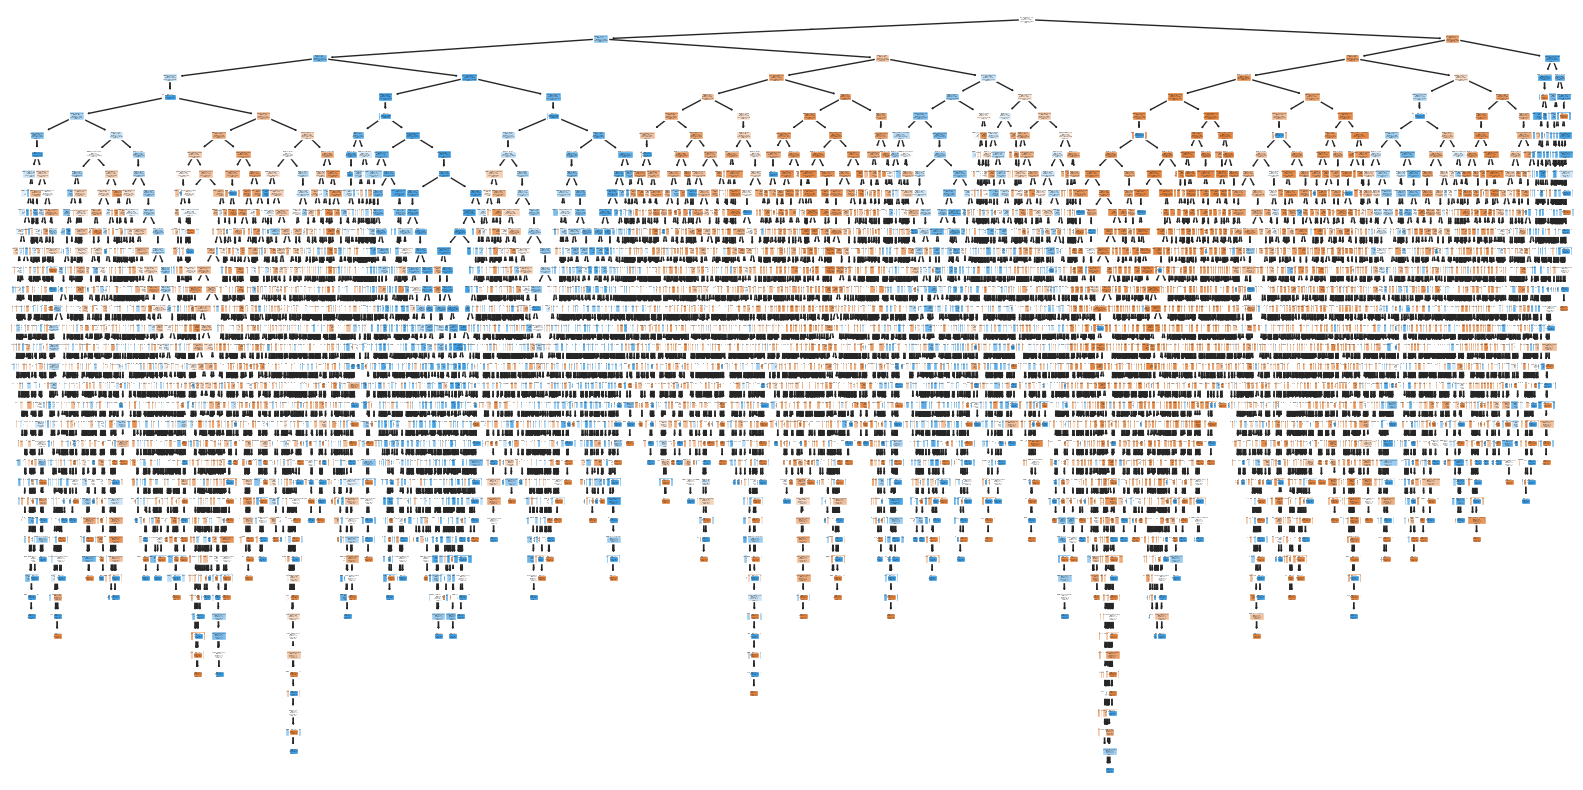

In [33]:
plt.figure(figsize = (20, 10))
plot_tree(
    arvore_churn,
    filled = True,
    feature_names = x_train.columns,
    class_names = ['0', '1']
)
plt.show()

### Realizando a Poda da Árvore

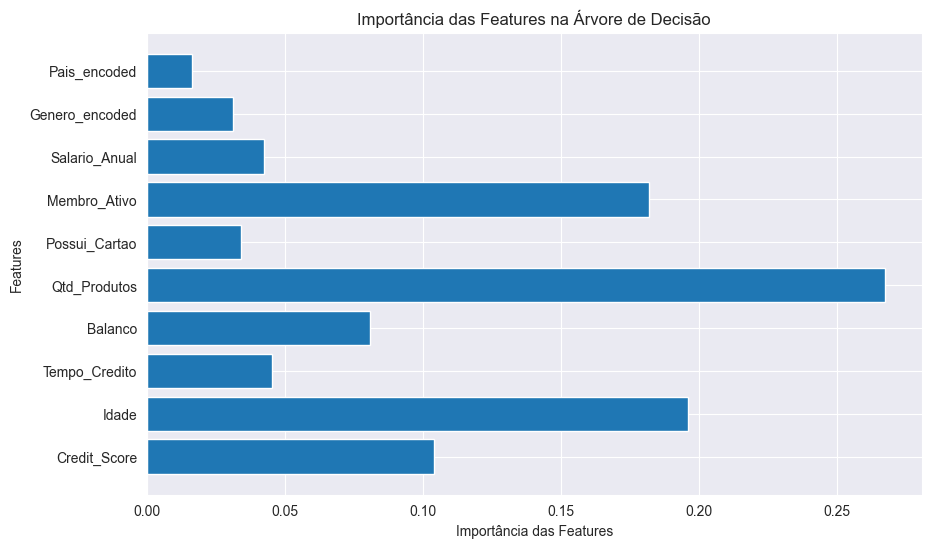

In [37]:
# Obtendo a importância das características do modelo
importancias_features = arvore_churn.feature_importances_

# Obtendo os nomes das características
nomes_features = x_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize = (10, 6))
plt.barh(
    nomes_features,
    importancias_features
)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

Visualizar as features com maior peso em um modelo de árvore de decisão ou qualquer outro modelo de aprendizado de máquina é uma etapa crucial na análise do modelo e na compreensão de como ele está tomando suas decisões. Aqui estão algumas razões pelas quais isso é importante:

Interpretabilidade do Modelo: Entender quais features são mais importantes para o modelo pode ajudar a interpretar como o modelo está tomando suas decisões. Isso pode ser especialmente útil em casos em que é importante entender os fatores que influenciam as previsões do modelo.
Seleção de Features: Ao identificar as features mais importantes, você pode decidir se deseja manter apenas as features mais relevantes e descartar as menos importantes. Isso pode ajudar a simplificar o modelo e reduzir a dimensionalidade dos dados, o que pode levar a um modelo mais simples e eficiente.

Rodando o modelo apenas com as principais características apontadas no gráfico acima

In [38]:
# Selecionando as principais variáveis
x_train_reduzido = x_train[['Qtd_Produtos', 'Membro_Ativo', 'Idade']]
x_test_reduzido = x_test[['Qtd_Produtos', 'Membro_Ativo', 'Idade']]

# Criando a árvore de decisão
arvore_churn_reduzida = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore_churn_reduzida.fit(x_train_reduzido, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [39]:
# Realizando as previsões na base de teste
previsoes_modelo_reduzido = arvore_churn_reduzida.predict(x_test_reduzido)

In [40]:
# Plotando o relatório de desempenho
relatorio = classification_report(y_test, previsoes_modelo_reduzido)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     19649
         1.0       0.74      0.48      0.59      5278

    accuracy                           0.85     24927
   macro avg       0.81      0.72      0.75     24927
weighted avg       0.84      0.85      0.84     24927



* Para a classe 0 (0.0): A precisão melhorou para 87%, o que significa que 87% das amostras previstas como pertencentes à classe 0 realmente são da classe 0.
* Para a classe 1 (1.0): A precisão também melhorou para 74%, indicando que 74% das amostras previstas como pertencentes à classe 1 realmente são da classe 1.
---
* Para a classe 0 (0.0): A revocação melhorou para 95%, indicando que o modelo identificou corretamente 95% das amostras da classe 0.
* Para a classe 1 (1.0): A revocação piorou para 48%, indicando que o modelo identificou corretamente 48% das amostras da classe 1.

### Matriz de Confusão do Modelo Reduzido

In [43]:
# MATRIZ DE CONFUSÃO
conf_matrix = confusion_matrix(y_test, previsoes_modelo_reduzido)

class_names = ['Não Churn', 'Churn']

# Matriz de Confusão
fig = ff.create_annotated_heatmap(
    z = conf_matrix,
    x = class_names,
    y = class_names,
    colorscale = 'Blues',
    showscale = True
)

# Estilizando
fig.update_layout(
    title = 'Matriz de Confusão',
    xaxis_title = 'Rótulos Previstos',
    yaxis_title = 'Rótulos Verdadeiros',
    font = dict(
        family = 'Arial',
        size = 12,
        color = 'black'
    ),
    template = 'plotly'
)

fig.show()

### Visualizando o Modelo Reduzido

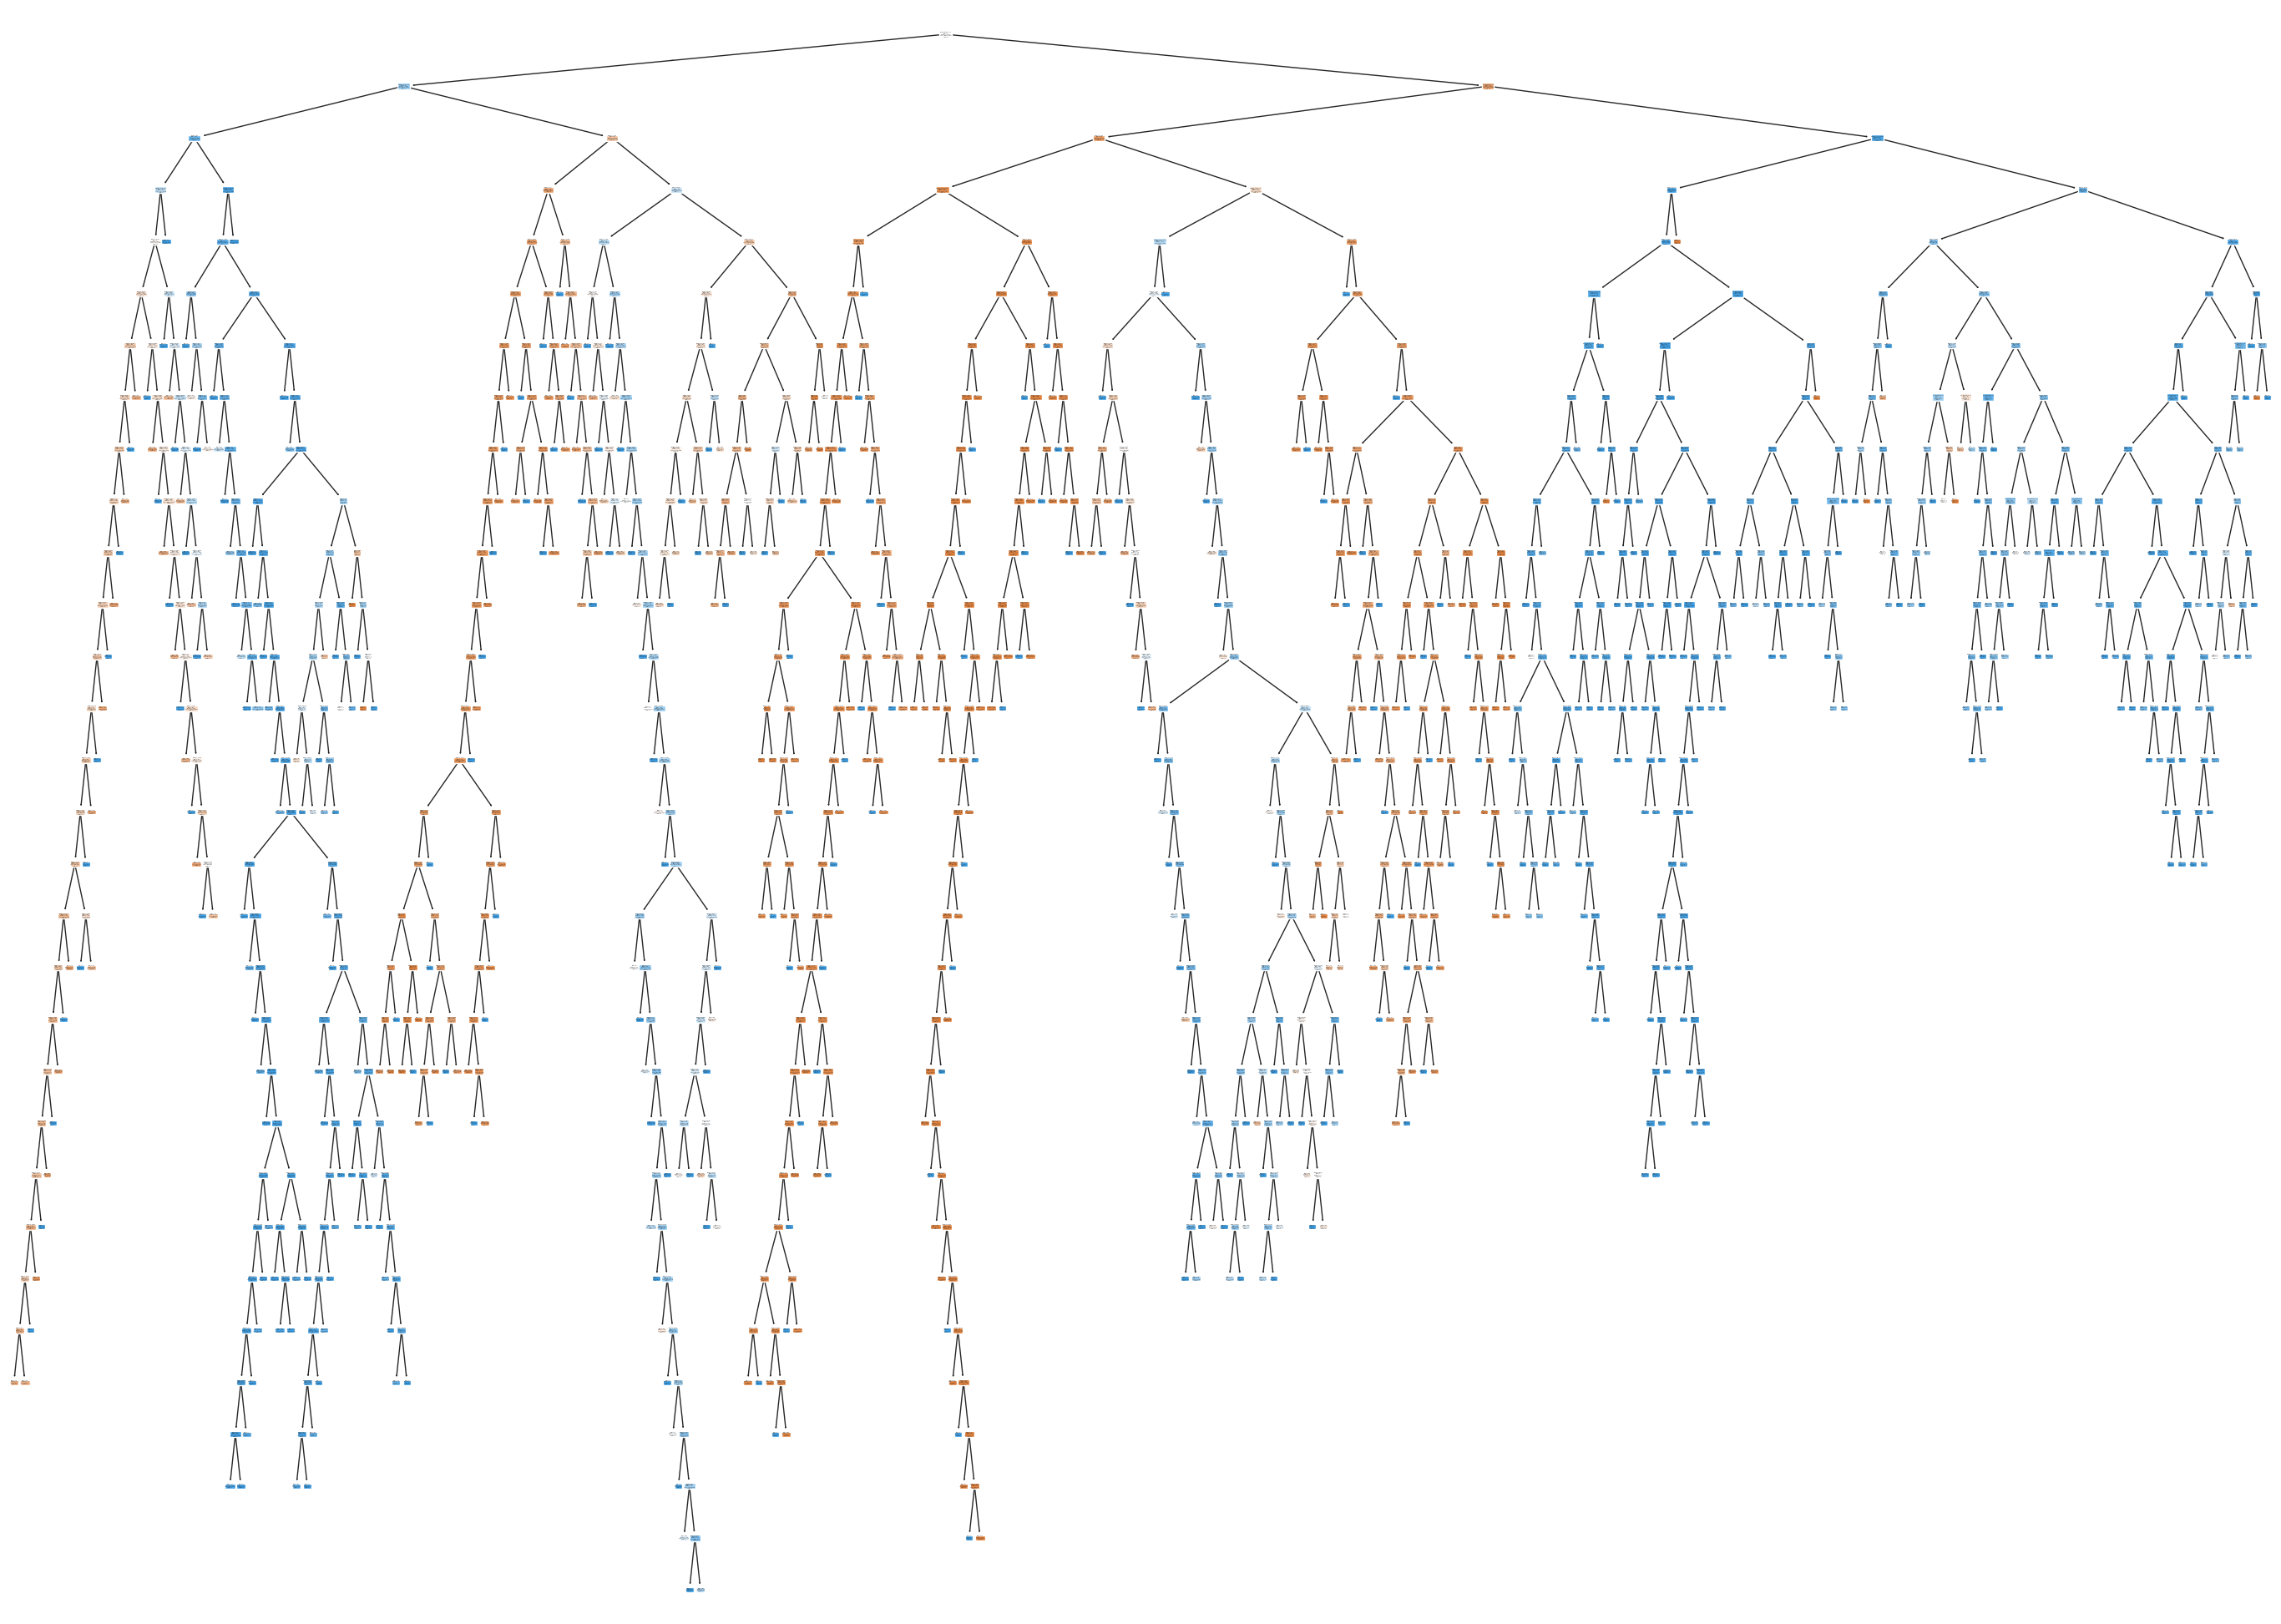

In [45]:
plt.figure(figsize = (35, 25))
plot_tree(
    arvore_churn_reduzida,
    filled = True,
    feature_names = x_train_reduzido.columns,
    class_names = ['0', '1']
)
plt.show()

In [46]:
# Criando um modelo de árvore de decisão com profundidade 1
arvore_profundidade_1 = DecisionTreeClassifier(max_depth = 1, random_state = 42)
arvore_profundidade_1.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

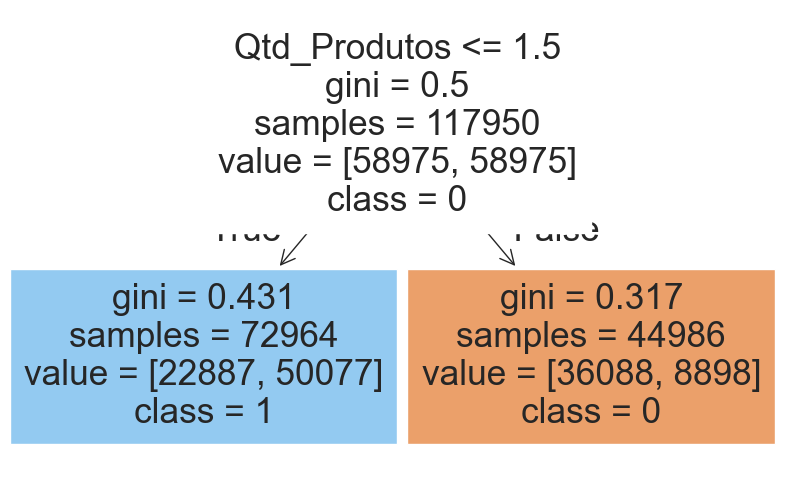

In [47]:
plt.figure(figsize = (10, 6))
plot_tree(
    arvore_profundidade_1,
    filled = True,
    feature_names = x_train.columns,
    class_names = ['0', '1']
)
plt.show()

Neste exemplo, max_depth=1 cria uma árvore de decisão com apenas um nível (a raiz e uma divisão). Notem que ele usou a feature de maior importancia, o melhor valor de Gini.


Na representação visual de uma árvore de decisão, os valores que aparecem dentro dos colchetes, especificamente sob o atributo value, fornecem informações sobre a distribuição das classes (ou categorias) de destino em um nó específico da árvore.
[200, 150] -> Isso significa que há 200 exemplos de treinamento nesse nó e, desses, 150 são da classe 0 e 50 são da classe 1.

Interpretar uma árvore de decisão é crucial para compreender como o modelo toma decisões, identificar padrões nos dados, ajustar o modelo adequadamente, comunicar resultados de forma clara e garantir a confiabilidade do modelo em diferentes contextos.


Mas notem que: Nosso problema acabou sendo muito complexo para uma árvore de decisão, um dos benefícios da árvore é a facilidade da interpretação mas um problema complexo como o nosso, com  diversas features e categorias, não permite uma fácil interpretação da árvore, por isso, nos aprofundaremos em modelos mais robustos.